In [4]:
# Instalar y/o cargar todos los paquetes de una vez
if (!require("pacman")) {
  install.packages("pacman")
}
# Cargar paquetes necesarios para el análisis
pacman::p_load(
  factoextra,
  readr,
  FactoMineR,
  GGally,
  ggplot2,
  missMDA,
  corrplot,
  NbClust,
  cluster,
  fpc,
  dendextend,
  readxl,
  visdat,
  Hmisc,      # Load before tidyverse
  psych,      # Load before tidyverse
  tidyverse   # Loads dplyr last, ensuring its functions take precedence
)

Loading required package: pacman


### Cargar los datos

In [5]:
data_num_imputed <- read_csv(
  "C:/Users/user/CO2-emsiones-tipo-combustible/data/processed/data_num_imputed.csv"
)

str(data_num_imputed)

Rows: 23 Columns: 17
── Column specification ────────────────────────────────────────────────────────────────────
Delimiter: ","
dbl (17): Año, Total, Asfaltos, Avtur, Bagazo de caña, Carbón mineral, Coque, Diesel, Fu...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
spc_tbl_ [23 × 17] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ Año                    : num [1:23] 2000 2001 2002 2003 2004 ...
 $ Total                  : num [1:23] 22509 22065 24103 22033 21745 ...
 $ Asfaltos               : num [1:23] 65.5 77.9 72.8 24.2 30.9 ...
 $ Avtur                  : num [1:23] 478 536 247 523 666 ...
 $ Bagazo de caña         : num [1:23] 887 896 956 931 1029 ...
 $ Carbón mineral         : num [1:23] 254 410 1313 1882 2624 ...
 $ Coque                  : num [1:23] 218 319 426 281 862 ...
 $ Diesel                 : num [1:23] 6186 4719 4592 3284 3292 ...
 $ Fuel oil               : num 

### correlación

In [6]:
correlaciones <- cor(data_num_imputed[, -c(1, 2)])
cor_res <- rcorr(as.matrix(data_num_imputed[, -c(1, 2)]))  
cor_mat <- cor_res$r
p_mat <- cor_res$P

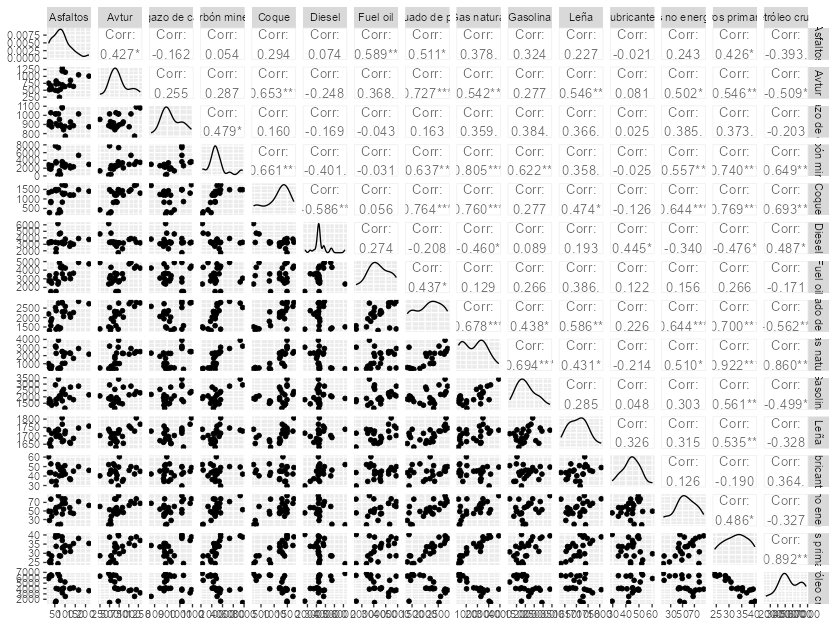

In [7]:
ggpairs(data_num_imputed[, -c(1, 2)])

Warning message:
package ‘ggcorrplot’ was built under R version 4.5.3 


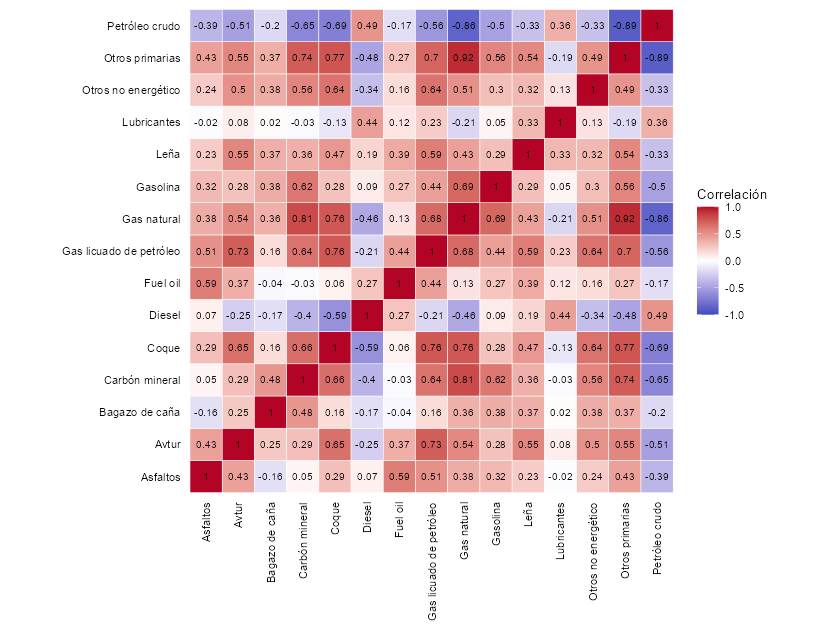

In [8]:
library(ggcorrplot)
library(ggplot2)

grafico_cor <- ggcorrplot(
  correlaciones,
  method = "square",
  type = "full",
  lab = TRUE,
  lab_col = "black",
  lab_size = 3,
  digits = 2,
  colors = c("#3B4CC0", "white", "#B40426"),
  outline.color = "white",
  show.diag = TRUE,
  legend.title = "Correlación"
) +
  theme_minimal() +
  theme(
    axis.title = element_blank(),
    axis.text.x = element_text(
      angle = 90,
      hjust = 1,
      vjust = 0.5,
      size = 9,
      color = "black"
    ),
    axis.text.y = element_text(
      size = 9,
      color = "black"
    ),
    panel.grid = element_blank(),
    plot.margin = margin(5, 5, 5, 5)
  )

grafico_cor

In [9]:
ggsave(
  filename = "C:/Users/user/CO2-emsiones-tipo-combustible/results/figures/matriz_correlacion.tiff",
  plot = grafico_cor,
  width = 12,
  height = 10,
  units = "in",
  dpi = 400,
  compression = "lzw",
  bg = "white"
)

### Diagnóstico adecuado para decidir si se puede aplicar PCA

In [10]:
det_cor <- det(cor_mat)
eig_vals <- eigen(cor_mat)$values
var_explained <- eig_vals / sum(eig_vals)
cum_var <- cumsum(var_explained)
n_eig_gt1 <- sum(eig_vals > 1)

In [11]:
corr_analysis <- list(
  correlation = cor_mat,
  p_values = p_mat,
  determinant = det_cor,
  eigenvalues = eig_vals,
  variance_explained = var_explained,
  cumulative_variance = cum_var,
  n_eigen_gt1 = n_eig_gt1
)

corr_analysis

$correlation
                           Asfaltos       Avtur Bagazo de caña Carbón mineral       Coque
Asfaltos                 1.00000000  0.42735097    -0.16241617     0.05447673  0.29400326
Avtur                    0.42735097  1.00000000     0.25494677     0.28652272  0.65261091
Bagazo de caña          -0.16241617  0.25494677     1.00000000     0.47875940  0.16000367
Carbón mineral           0.05447673  0.28652272     0.47875940     1.00000000  0.66114944
Coque                    0.29400326  0.65261091     0.16000367     0.66114944  1.00000000
Diesel                   0.07392170 -0.24795141    -0.16934470    -0.40081995 -0.58641603
Fuel oil                 0.58894907  0.36757536    -0.04277410    -0.03110839  0.05639386
Gas licuado de petróleo  0.51080130  0.72737379     0.16284285     0.63723488  0.76420599
Gas natural              0.37757117  0.54180493     0.35924964     0.80530624  0.76004092
Gasolina                 0.32419242  0.27744679     0.38400289     0.62232152  0.276874

### Medida de adecuación muestral de Kaiser-Meyer-Olkin (KMO)

In [12]:
library(psych)
KMO(data_num_imputed[, -c(1, 2)])

Kaiser-Meyer-Olkin factor adequacy
Call: KMO(r = data_num_imputed[, -c(1, 2)])
Overall MSA =  0.62
MSA for each item = 
               Asfaltos                   Avtur          Bagazo de caña 
                   0.67                    0.61                    0.35 
         Carbón mineral                   Coque                  Diesel 
                   0.70                    0.67                    0.41 
               Fuel oil Gas licuado de petróleo             Gas natural 
                   0.40                    0.74                    0.75 
               Gasolina                    Leña             Lubricantes 
                   0.51                    0.44                    0.34 
    Otros no energético         Otros primarias          Petróleo crudo 
                   0.73                    0.76                    0.75 

### Prueba de esfericidad de Bartlett

In [13]:
cor_for_bartlett <- cor(data_num_imputed[, -c(1, 2)])
bartlett_res <- cortest.bartlett(cor_for_bartlett, n = nrow(data_num_imputed))
bartlett_res

$chisq
[1] 284.8567

$p.value
[1] 1.58143e-18

$df
[1] 105


#### Eliminar variables de baja MSA (MSA < 0,5)

In [14]:
kmo_result <- KMO(data_num_imputed[, -c(1, 2)])
msa_values <- kmo_result$MSAi
low_msa_vars <- names(msa_values[msa_values < 0.5])
cat("Eliminar variables de baja MSA:", paste(low_msa_vars, collapse = ", "), "\n")

Eliminar variables de baja MSA: Bagazo de caña, Diesel, Fuel oil, Leña, Lubricantes 


#### Crear conjunto de datos filtrado (mantener Año y Total, eliminar variables de combustible MSA bajas)

In [15]:
cols_to_keep <- !colnames(data_num_imputed) %in% low_msa_vars
data_filtered <- data_num_imputed[, cols_to_keep]

#### Volver a calcular los diagnósticos en los datos filtrados

In [16]:
correlaciones_filtered <- cor(data_filtered[, -c(1, 2)])
cor_res_filtered <- rcorr(as.matrix(data_filtered[, -c(1, 2)]))  
cor_mat_filtered <- cor_res_filtered$r
p_mat_filtered <- cor_res_filtered$P

In [17]:
det_cor_filtered <- det(cor_mat_filtered)
eig_vals_filtered <- eigen(cor_mat_filtered)$values
var_explained_filtered <- eig_vals_filtered / sum(eig_vals_filtered)
cum_var_filtered <- cumsum(var_explained_filtered)
n_eig_gt1_filtered <- sum(eig_vals_filtered > 1)

#### KMO y Bartlett en datos filtrados

In [18]:
kmo_filtered <- KMO(data_filtered[, -c(1, 2)])
bartlett_filtered <- cortest.bartlett(
  cor(data_filtered[, -c(1, 2)]),
  n = nrow(data_filtered)
)

cat("\n=== Filtered Data Diagnostics ===\n")


=== Filtered Data Diagnostics ===


In [19]:
KMO(data_filtered[, -c(1, 2)])

Kaiser-Meyer-Olkin factor adequacy
Call: KMO(r = data_filtered[, -c(1, 2)])
Overall MSA =  0.78
MSA for each item = 
               Asfaltos                   Avtur          Carbón mineral 
                   0.52                    0.69                    0.68 
                  Coque Gas licuado de petróleo             Gas natural 
                   0.86                    0.73                    0.84 
               Gasolina     Otros no energético         Otros primarias 
                   0.73                    0.85                    0.89 
         Petróleo crudo 
                   0.85 

In [20]:
cat("Bartlett p-value:", bartlett_filtered$p.value, "\n")

Bartlett p-value: 2.917679e-20 


In [21]:
bartlett_filtered$chisq


[1] 193.1396

In [22]:
bartlett_filtered$df


[1] 45

In [23]:
bartlett_filtered$p.value

[1] 2.917679e-20

In [24]:
cat("Determinant:", det_cor_filtered, "\n")

Determinant: 1.979145e-05 


In [25]:
cat("Eigenvalues > 1:", n_eig_gt1_filtered, "\n")

Eigenvalues > 1: 2 


In [26]:
cat(
  "Cumulative variance (first 4 PCs):",
  cum_var_filtered[1:min(4, length(cum_var_filtered))],
  "\n"
)

Cumulative variance (first 4 PCs): 0.6118039 0.729904 0.8281602 0.8967972 


## Análisis de Componentes Principales (PCA)

In [28]:
pca <- prcomp(data_filtered[, -c(1, 2)], scale. = TRUE)
set.seed(123)

### estabilidad mediante bootstrap

Dado que la data es relativamente pequeña, se procede a realizar una pureba de estabilidad mediente boostrap.

Como no se tiene otra muestra, el bootstrap crea muchas "muestras nuevas" a partir de la original.

In [29]:
data_pca <- data_filtered[, -c(1, 2)]

In [30]:
dim(data_pca)

[1] 23 10

In [31]:
names(data_pca)

 [1] "Asfaltos"                "Avtur"                   "Carbón mineral"         
 [4] "Coque"                   "Gas licuado de petróleo" "Gas natural"            
 [7] "Gasolina"                "Otros no energético"     "Otros primarias"        
[10] "Petróleo crudo"         

In [32]:
set.seed(123)

B <- 1000
n <- nrow(data_pca)
p <- ncol(data_pca)

In [33]:
n


[1] 23

In [34]:
p

[1] 10

In [35]:
cargas_boot <- array(
  NA_real_,
  dim = c(p, 2, B),
  dimnames = list(
    variable = colnames(data_pca),
    componente = c("PC1", "PC2"),
    replica = paste0("B", 1:B)
  )
)

varianza_boot <- matrix(
  NA_real_,
  nrow = B,
  ncol = 2,
  dimnames = list(
    replica = paste0("B", 1:B),
    componente = c("PC1", "PC2")
  )
)

In [36]:
dim(cargas_boot)


[1]   10    2 1000

In [37]:
dim(varianza_boot)

[1] 1000    2

In [38]:
# Cargas de referencia del PCA original
cargas_ref <- pca$rotation[, 1:2, drop = FALSE]

# Registrar cuáles réplicas se calcularon correctamente
replicas_validas <- logical(B)

for (b in seq_len(B)) {

  # 1. Seleccionar 23 filas con reemplazo
  indices <- sample(
    seq_len(n),
    size = n,
    replace = TRUE
  )

  datos_b <- data_pca[indices, , drop = FALSE]

  # 2. Comprobar que ninguna variable quede constante
  desvios <- vapply(
    datos_b,
    sd,
    numeric(1),
    na.rm = TRUE
  )

  if (any(!is.finite(desvios) | desvios == 0)) {
    next
  }

  # 3. Calcular el PCA de la réplica
  pca_b <- tryCatch(
    prcomp(
      datos_b,
      center = TRUE,
      scale. = TRUE
    ),
    error = function(e) NULL
  )

  if (is.null(pca_b)) {
    next
  }

  cargas_b <- pca_b$rotation

  varianza_b <- 100 * (
    pca_b$sdev^2 / sum(pca_b$sdev^2)
  )

  componentes_usados <- integer(0)

  # 4. Identificar y alinear PC1 y PC2
  for (j in 1:2) {

    similitud <- as.numeric(
      crossprod(cargas_ref[, j], cargas_b)
    )

    if (length(componentes_usados) > 0) {
      similitud[componentes_usados] <- NA_real_
    }

    componente_b <- which.max(abs(similitud))

    # Corregir posibles cambios de signo
    if (similitud[componente_b] < 0) {
      cargas_b[, componente_b] <-
        -cargas_b[, componente_b]
    }

    cargas_boot[, j, b] <-
      cargas_b[, componente_b]

    varianza_boot[b, j] <-
      varianza_b[componente_b]

    componentes_usados <- c(
      componentes_usados,
      componente_b
    )
  }

  replicas_validas[b] <- TRUE
}

In [39]:
sum(replicas_validas)

[1] 1000

In [40]:
varianza_original <- 100 * (
  pca$sdev^2 / sum(pca$sdev^2)
)

resumen_varianza <- data.frame(
  Componente = c("PC1", "PC2"),

  Varianza_original = varianza_original[1:2],

  Media_bootstrap = colMeans(
    varianza_boot,
    na.rm = TRUE
  ),

  IC_95_inferior = apply(
    varianza_boot,
    2,
    quantile,
    probs = 0.025,
    na.rm = TRUE
  ),

  IC_95_superior = apply(
    varianza_boot,
    2,
    quantile,
    probs = 0.975,
    na.rm = TRUE
  )
)

In [41]:
resumen_varianza

    Componente Varianza_original Media_bootstrap IC_95_inferior IC_95_superior
PC1        PC1          61.18039        62.06884      51.727690       72.53609
PC2        PC2          11.81001        12.09953       2.554658       19.03904

In [42]:
resumen_cargas <- do.call(
  rbind,
  lapply(1:2, function(j) {

    data.frame(
      Variable = rownames(cargas_ref),
      Componente = paste0("PC", j),

      Carga_original = cargas_ref[, j],

      Media_bootstrap = apply(
        cargas_boot[, j, , drop = FALSE],
        1,
        mean,
        na.rm = TRUE
      ),

      IC_95_inferior = apply(
        cargas_boot[, j, , drop = FALSE],
        1,
        quantile,
        probs = 0.025,
        na.rm = TRUE
      ),

      IC_95_superior = apply(
        cargas_boot[, j, , drop = FALSE],
        1,
        quantile,
        probs = 0.975,
        na.rm = TRUE
      )
    )
  })
)

In [43]:
resumen_cargas[, 3:6] <- round(
  resumen_cargas[, 3:6],
  3
)

resumen_cargas

                                        Variable Componente Carga_original Media_bootstrap
Asfaltos                                Asfaltos        PC1          0.196           0.192
Avtur                                      Avtur        PC1          0.282           0.280
Carbón mineral                    Carbón mineral        PC1          0.323           0.325
Coque                                      Coque        PC1          0.347           0.343
Gas licuado de petróleo  Gas licuado de petróleo        PC1          0.346           0.342
Gas natural                          Gas natural        PC1          0.379           0.378
Gasolina                                Gasolina        PC1          0.257           0.253
Otros no energético          Otros no energético        PC1          0.270           0.261
Otros primarias                  Otros primarias        PC1          0.374           0.373
Petróleo crudo                    Petróleo crudo        PC1         -0.340          -0.341

In [44]:
library(dplyr)

resumen_cargas <- resumen_cargas |>
  mutate(
    Estabilidad = case_when(
      IC_95_inferior > 0 ~ "Estable positiva",
      IC_95_superior < 0 ~ "Estable negativa",
      TRUE ~ "Inestable: incluye cero"
    )
  )

rownames(resumen_cargas) <- NULL

In [45]:
resumen_cargas |>
  as_tibble() |>
  print(n = Inf, width = Inf)

# A tibble: 20 × 7
   Variable                Componente Carga_original Media_bootstrap IC_95_inferior
   <chr>                   <chr>               <dbl>           <dbl>          <dbl>
 1 Asfaltos                PC1                 0.196           0.192          0.085
 2 Avtur                   PC1                 0.282           0.28           0.18 
 3 Carbón mineral          PC1                 0.323           0.325          0.287
 4 Coque                   PC1                 0.347           0.343          0.284
 5 Gas licuado de petróleo PC1                 0.346           0.342          0.273
 6 Gas natural             PC1                 0.379           0.378          0.354
 7 Gasolina                PC1                 0.257           0.253          0.144
 8 Otros no energético     PC1                 0.27            0.261          0.096
 9 Otros primarias         PC1                 0.374           0.373          0.35 
10 Petróleo crudo          PC1                -0.34      

Warning message:
In geom_bar(stat = "identity", fill = barfill, color = barcolor,  :
  Ignoring empty aesthetic: `width`.


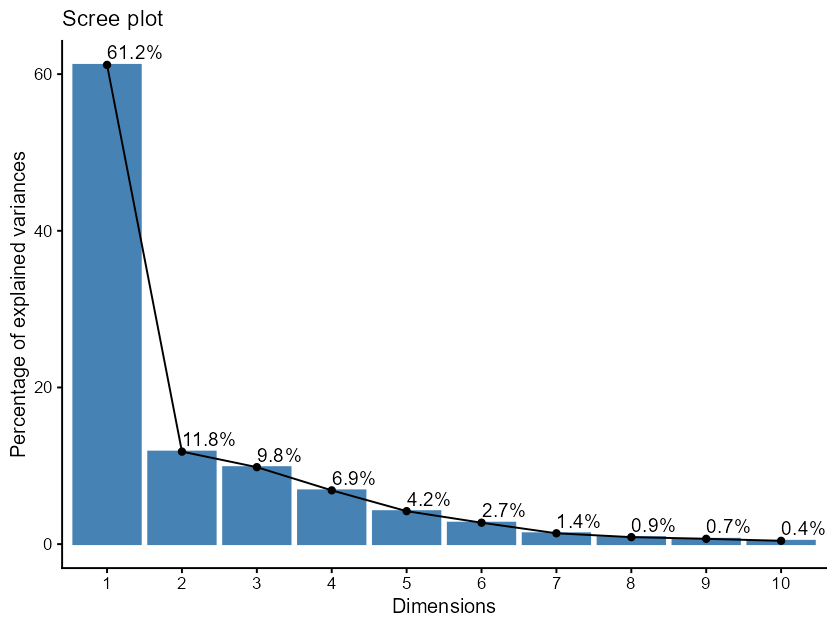

In [46]:
fviz_eig(
  pca,
  addlabels = TRUE,   
  labelsize = 6       
) +
  theme_classic(base_size = 16) +   
  theme(
    axis.text = element_text(size = 14),
    axis.title = element_text(size = 16),
    plot.title = element_text(size = 18)
  )

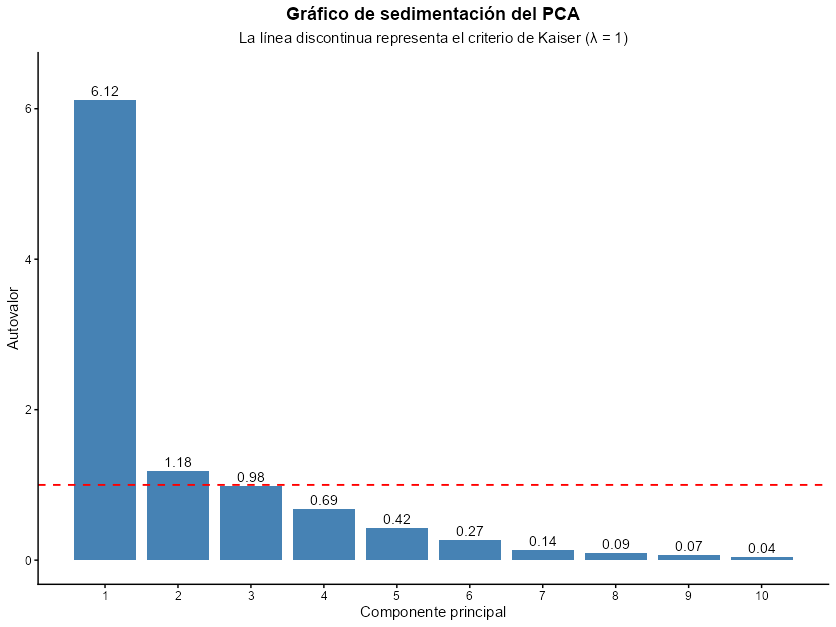

In [47]:
# Extraer autovalores del PCA
autovalores <- pca$sdev^2

datos_scree <- data.frame(
  Componente = seq_along(autovalores),
  Autovalor = autovalores
)

figura_sedimentacion <- ggplot(
  datos_scree,
  aes(x = Componente, y = Autovalor)
) +
  geom_col(
    fill = "steelblue",
    width = 0.85
  ) +
  geom_text(
    aes(label = round(Autovalor, 2)),
    vjust = -0.4,
    size = 4
  ) +
  geom_hline(
    yintercept = 1,
    linetype = "dashed",
    color = "red",
    linewidth = 0.7
  ) +
  scale_x_continuous(
    breaks = datos_scree$Componente
  ) +
  expand_limits(
    y = max(datos_scree$Autovalor) * 1.05
  ) +
  labs(
    title = "Gráfico de sedimentación del PCA",
    subtitle = "La línea discontinua representa el criterio de Kaiser (λ = 1)",
    x = "Componente principal",
    y = "Autovalor"
  ) +
  theme_classic(base_size = 12) +
  theme(
    plot.title = element_text(
      face = "bold",
      hjust = 0.5
    ),
    plot.subtitle = element_text(
      hjust = 0.5
    )
  )

figura_sedimentacion

In [48]:
ggsave(
  filename = paste0(
    "C:/Users/user/CO2-emsiones-tipo-combustible/",
    "results/figures/",
    "Grafico_sedimentacion_PCA.tiff"
  ),
  plot = figura_sedimentacion,
  width = 7,
  height = 5,
  units = "in",
  dpi = 400,
  compression = "lzw",
  bg = "white"
)

In [49]:
data_filtered_df <- as.data.frame(data_filtered)

years <- data_filtered_df$Año
rownames(data_filtered_df) <- years  

Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <]8;;https://github.com/kassambara/ggpubr/issueshttps://github.com/kassambara/ggpubr/issues]8;;>.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was generated. 


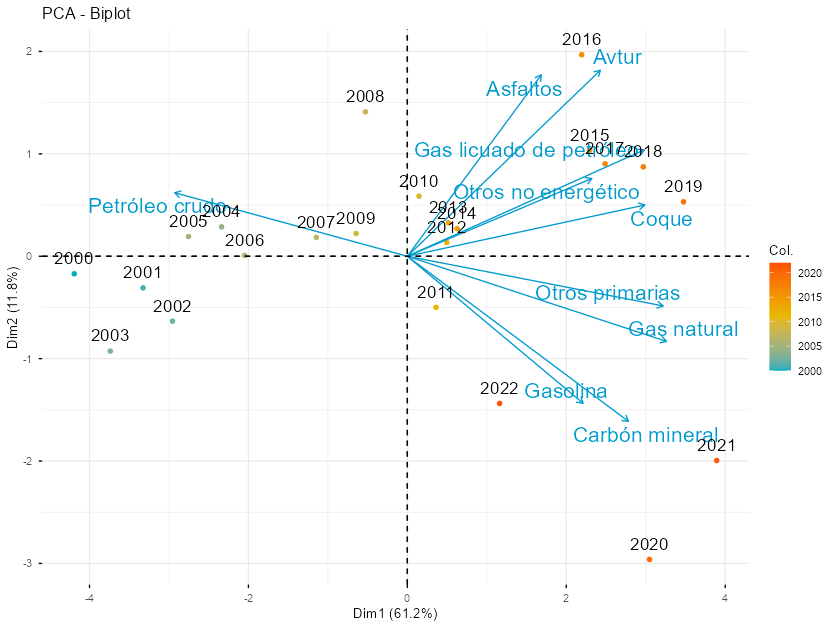

In [50]:
fviz_pca_biplot(
  pca,
  geom.ind = "point", # mostrar puntos
  labelsize = 6, # tamaño de letras
  label = "all", #  Mostrar etiquetas por defecto
  col.ind = years, # color por año
  gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"), # paleta para años
  col.var = "#009ACD", # color de vectores de variables
  repel = TRUE # evitar solapamiento
) +
  geom_text(
    aes(label = years), # añadir texto de los años
    vjust = -0.8,
    size = 5,
    color = "black"
  )

In [51]:
var_pca <- get_pca_var(pca)

print(var_pca$coord)

                             Dim.1      Dim.2       Dim.3       Dim.4       Dim.5
Asfaltos                 0.4841632  0.5086693  0.62480719 -0.15373519  0.29092387
Avtur                    0.6976866  0.5217839 -0.05051028  0.08457057 -0.46245992
Carbón mineral           0.7991835 -0.4631291 -0.24284925 -0.11675576  0.06994164
Coque                    0.8580590  0.1436709 -0.30686057  0.23284568  0.08231920
Gas licuado de petróleo  0.8564736  0.2983809 -0.10089711 -0.14455595 -0.04061341
Gas natural              0.9367571 -0.2388393  0.09570845  0.07492930 -0.01264138
Gasolina                 0.6352531 -0.4123537  0.36463448 -0.46341952 -0.24076366
Otros no energético      0.6668372  0.2181097 -0.47881274 -0.39226774  0.20166187
Otros primarias          0.9246611 -0.1393788  0.10738447  0.21041933  0.09235488
Petróleo crudo          -0.8412022  0.1782102 -0.20831866 -0.38511760 -0.04156671
                              Dim.6       Dim.7       Dim.8       Dim.9      Dim.10
Asfaltos      

In [52]:
print(var_pca$contrib)

                            Dim.1     Dim.2      Dim.3      Dim.4       Dim.5      Dim.6
Asfaltos                 3.831522 21.908911 39.7312014  3.4434065 20.10968618  0.2291145
Avtur                    7.956252 23.053196  0.2596565  1.0420299 50.81533461  2.9311043
Carbón mineral          10.439528 18.161595  6.0022378  1.9860872  1.16229984 12.6263086
Coque                   12.034334  1.747782  9.5834493  7.8991084  1.61008522  0.9602025
Gas licuado de petróleo 11.989904  7.538618  1.0360890  3.0444835  0.39190926 44.5885911
Gas natural             14.343060  4.830160  0.9322668  0.8179845  0.03796953  2.1846234
Gasolina                 6.596012 14.397580 13.5317862 31.2889033 13.77299667  1.0960363
Otros no energético      7.268209  4.028095 23.3330254 22.4185171  9.66260367 28.8036149
Otros primarias         13.975036  1.644915  1.1736068  6.4507905  2.02659171  0.6868093
Petróleo crudo          11.566144  2.689149  4.4166807 21.6086892  0.41052332  5.8935951
                     

In [53]:
print(var_pca$cos2)

                            Dim.1      Dim.2       Dim.3       Dim.4        Dim.5
Asfaltos                0.2344140 0.25874444 0.390384020 0.023634510 0.0846366978
Avtur                   0.4867665 0.27225846 0.002551288 0.007152181 0.2138691813
Carbón mineral          0.6386943 0.21448861 0.058975758 0.013631907 0.0048918327
Coque                   0.7362652 0.02064132 0.094163411 0.054217112 0.0067764506
Gas licuado de petróleo 0.7335470 0.08903115 0.010180226 0.020896422 0.0016494492
Gas natural             0.8775140 0.05704423 0.009160107 0.005614400 0.0001598044
Gasolina                0.4035466 0.17003556 0.132958302 0.214757653 0.0579671382
Otros no energético     0.4446718 0.04757183 0.229261637 0.153873981 0.0406675101
Otros primarias         0.8549981 0.01942646 0.011531424 0.044276292 0.0085294235
Petróleo crudo          0.7076212 0.03175888 0.043396663 0.148315565 0.0017277912
                               Dim.6        Dim.7        Dim.8        Dim.9       Dim.10
Asfaltos 

In [54]:
ind_pca <- get_pca_ind(pca)

print(ind_pca$coord)

        Dim.1        Dim.2       Dim.3       Dim.4       Dim.5        Dim.6        Dim.7
1  -4.1919178 -0.171506702  1.18780982 -0.27855922 -0.59912438 -0.372320754  0.030639978
2  -3.3259267 -0.308613479  1.58259331  0.20197908 -0.49792929  0.012158796 -0.189175901
3  -2.9551597 -0.633791049  0.24070395 -1.23416795  0.98072179  0.794949617 -0.155737804
4  -3.7380973 -0.925836390  0.20537457 -0.12725298 -0.72054339  0.007650985 -0.279357049
5  -2.3377256  0.286742067 -1.76530765 -1.06678076  0.06014147  0.840169737 -0.115859147
6  -2.7538877  0.192185966 -0.94629143 -0.17717059 -0.19569458 -0.156152266 -0.007647291
7  -2.0473748  0.008514715 -1.13208036  0.63035058  0.16776375 -0.927208839  0.804194166
8  -1.1457710  0.183348702 -1.47385476  0.39594585 -0.46283803 -0.610988339  0.295146222
9  -0.5274865  1.409887215 -1.23735647 -0.06675113  1.36240219  0.058158932 -0.237828303
10 -0.6442352  0.222078285  0.36317079  0.52660093  0.11473408 -0.521764759 -0.851393827
11  0.1468999  0.5866

In [55]:
print(ind_pca$cos2)

         Dim.1        Dim.2        Dim.3        Dim.4        Dim.5        Dim.6
1  0.892691949 1.494302e-03 7.167537e-02 0.0039419506 1.823518e-02 7.042236e-03
2  0.786554774 6.772257e-03 1.780911e-01 0.0029007908 1.762946e-02 1.051199e-05
3  0.696156898 3.202119e-02 4.618614e-03 0.1214209866 7.667201e-02 5.037609e-02
4  0.891469991 5.468573e-02 2.690908e-03 0.0010330979 3.312271e-02 3.734567e-06
5  0.498451835 7.499270e-03 2.842346e-01 0.1037974031 3.299015e-04 6.438285e-02
6  0.880733842 4.289390e-03 1.039925e-01 0.0036453185 4.447437e-03 2.831710e-03
7  0.561186106 9.706272e-06 1.715800e-01 0.0531956968 3.767979e-03 1.150979e-01
8  0.300302757 7.689876e-03 4.969046e-01 0.0358620630 4.900289e-02 8.539442e-02
9  0.048292359 3.450043e-01 2.657330e-01 0.0007733445 3.221562e-01 5.870683e-04
10 0.212080313 2.520134e-02 6.739586e-02 0.1417015722 6.726611e-03 1.391108e-01
11 0.007949399 1.267945e-01 3.643344e-01 0.1166046946 2.825546e-01 7.109343e-02
12 0.096063075 1.834735e-01 2.580673e-01

In [56]:
tabla_var_pca <- data.frame(
  Variable = rownames(var_pca$contrib),
  Contrib_PC1 = var_pca$contrib[, 1],
  Contrib_PC2 = var_pca$contrib[, 2],
  Cos2_PC1 = var_pca$cos2[, 1],
  Cos2_PC2 = var_pca$cos2[, 2]
) |>
  arrange(desc(Contrib_PC1))

tabla_var_pca

                                       Variable Contrib_PC1 Contrib_PC2  Cos2_PC1
Gas natural                         Gas natural   14.343060    4.830160 0.8775140
Otros primarias                 Otros primarias   13.975036    1.644915 0.8549981
Coque                                     Coque   12.034334    1.747782 0.7362652
Gas licuado de petróleo Gas licuado de petróleo   11.989904    7.538618 0.7335470
Petróleo crudo                   Petróleo crudo   11.566144    2.689149 0.7076212
Carbón mineral                   Carbón mineral   10.439528   18.161595 0.6386943
Avtur                                     Avtur    7.956252   23.053196 0.4867665
Otros no energético         Otros no energético    7.268209    4.028095 0.4446718
Gasolina                               Gasolina    6.596012   14.397580 0.4035466
Asfaltos                               Asfaltos    3.831522   21.908911 0.2344140
                          Cos2_PC2
Gas natural             0.05704423
Otros primarias         0.01

In [57]:
library(dplyr)
library(tidyr)
library(tibble)
library(knitr)

# ---------------------------------------------------------
# 1. Autovalores y varianza explicada
# ---------------------------------------------------------

autovalores <- pca$sdev^2

tabla_varianza <- tibble(
  Componente = colnames(pca$rotation),
  Autovalor = autovalores,
  `Varianza explicada (%)` =
    autovalores / sum(autovalores) * 100,
  `Varianza acumulada (%)` =
    cumsum(autovalores / sum(autovalores) * 100)
)

# Componentes retenidos mediante el criterio de Kaiser
componentes_retenidos <- tabla_varianza |>
  filter(Autovalor > 1) |>
  pull(Componente)

# ---------------------------------------------------------
# 2. Correlaciones variable-componente
# ---------------------------------------------------------

# Equivale a get_pca_var(pca)$coord
cargas_correlacionales <- sweep(
  pca$rotation,
  MARGIN = 2,
  STATS = pca$sdev,
  FUN = "*"
)

# ---------------------------------------------------------
# 3. Seleccionar las principales cargas
# ---------------------------------------------------------

principales_cargas <- as.data.frame(
  cargas_correlacionales[
    ,
    componentes_retenidos,
    drop = FALSE
  ]
) |>
  rownames_to_column("Variable") |>
  pivot_longer(
    cols = -Variable,
    names_to = "Componente",
    values_to = "Carga"
  ) |>
  group_by(Componente) |>
  arrange(desc(abs(Carga)), .by_group = TRUE) |>
  slice_head(n = 5) |>
  summarise(
    `Principales cargas` = paste(
      sprintf("%s (%+.3f)", Variable, Carga),
      collapse = "; "
    ),
    .groups = "drop"
  )

# ---------------------------------------------------------
# 4. Unir resultados
# ---------------------------------------------------------

tabla_pca <- tabla_varianza |>
  filter(Componente %in% componentes_retenidos) |>
  left_join(principales_cargas, by = "Componente") |>
  mutate(
    Autovalor = round(Autovalor, 3),
    `Varianza explicada (%)` =
      round(`Varianza explicada (%)`, 2),
    `Varianza acumulada (%)` =
      round(`Varianza acumulada (%)`, 2)
  )

knitr::kable(
  tabla_pca,
  caption = paste(
    "Autovalores, varianza explicada y principales",
    "correlaciones variable-componente del PCA."
  ),
  align = c("l", "r", "r", "r", "l")
)



Table: Autovalores, varianza explicada y principales correlaciones variable-componente del PCA.

|Componente | Autovalor| Varianza explicada (%)| Varianza acumulada (%)|Principales cargas                                                                                                        |
|:----------|---------:|----------------------:|----------------------:|:-------------------------------------------------------------------------------------------------------------------------|
|PC1        |     6.118|                  61.18|                  61.18|Gas natural (+0.937); Otros primarias (+0.925); Coque (+0.858); Gas licuado de petróleo (+0.856); Petróleo crudo (-0.841) |
|PC2        |     1.181|                  11.81|                  72.99|Avtur (+0.522); Asfaltos (+0.509); Carbón mineral (-0.463); Gasolina (-0.412); Gas licuado de petróleo (+0.298)           |

In [58]:
tabla_cargas <- as.data.frame(
  cargas_correlacionales[
    ,
    componentes_retenidos,
    drop = FALSE
  ]
) |>
  rownames_to_column("Variable") |>
  mutate(
    across(
      -Variable,
      ~ round(.x, 3)
    )
  )

knitr::kable(
  tabla_cargas,
  caption = paste(
    "Correlaciones entre las variables originales",
    "y los componentes principales retenidos."
  ),
  align = c("l", "r", "r")
)



Table: Correlaciones entre las variables originales y los componentes principales retenidos.

|Variable                |    PC1|    PC2|
|:-----------------------|------:|------:|
|Asfaltos                |  0.484|  0.509|
|Avtur                   |  0.698|  0.522|
|Carbón mineral          |  0.799| -0.463|
|Coque                   |  0.858|  0.144|
|Gas licuado de petróleo |  0.856|  0.298|
|Gas natural             |  0.937| -0.239|
|Gasolina                |  0.635| -0.412|
|Otros no energético     |  0.667|  0.218|
|Otros primarias         |  0.925| -0.139|
|Petróleo crudo          | -0.841|  0.178|

In [59]:
str(data_filtered)

tibble [23 × 12] (S3: tbl_df/tbl/data.frame)
 $ Año                    : num [1:23] 2000 2001 2002 2003 2004 ...
 $ Total                  : num [1:23] 22509 22065 24103 22033 21745 ...
 $ Asfaltos               : num [1:23] 65.5 77.9 72.8 24.2 30.9 ...
 $ Avtur                  : num [1:23] 478 536 247 523 666 ...
 $ Carbón mineral         : num [1:23] 254 410 1313 1882 2624 ...
 $ Coque                  : num [1:23] 218 319 426 281 862 ...
 $ Gas licuado de petróleo: num [1:23] 1506 1448 1400 1317 1569 ...
 $ Gas natural            : num [1:23] 382 427 478 537 309 ...
 $ Gasolina               : num [1:23] 1878 2012 2076 1825 1631 ...
 $ Otros no energético    : num [1:23] 17.7 18.9 60.5 27.9 77.6 ...
 $ Otros primarias        : num [1:23] 24.3 28.5 28.7 25.3 24.4 ...
 $ Petróleo crudo         : num [1:23] 6811 5532 6308 6319 6440 ...


## Análisis de conglomerados (k-means y jerárquico)

In [60]:
X_cluster <- scale(data_filtered_df[, -c(1, 2)])
rownames(X_cluster) <- years

Warning message:
`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <]8;;https://github.com/kassambara/factoextra/issueshttps://github.com/kassambara/factoextra/issues]8;;>.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was generated. 


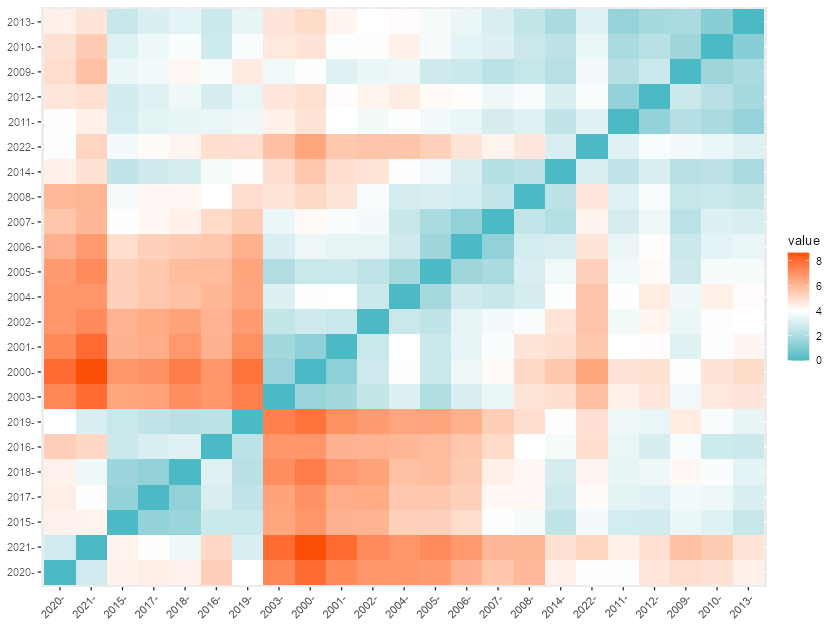

In [61]:
m.distancia <- get_dist(X_cluster, method = "euclidean")
fviz_dist(
  m.distancia,
  gradient = list(low = "#00AFBB", mid = "white", high = "#FC4E07")
)

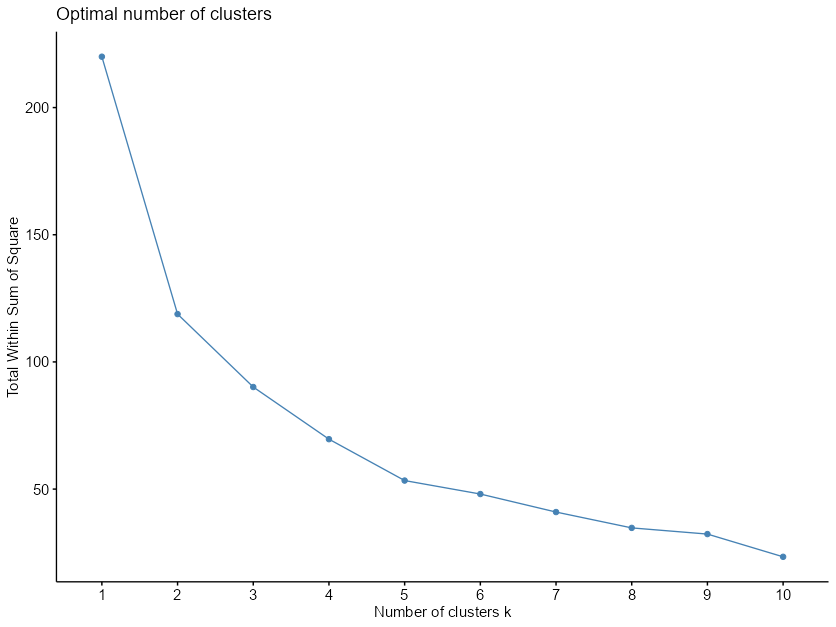

In [62]:
fviz_nbclust(X_cluster, kmeans, method = "wss")

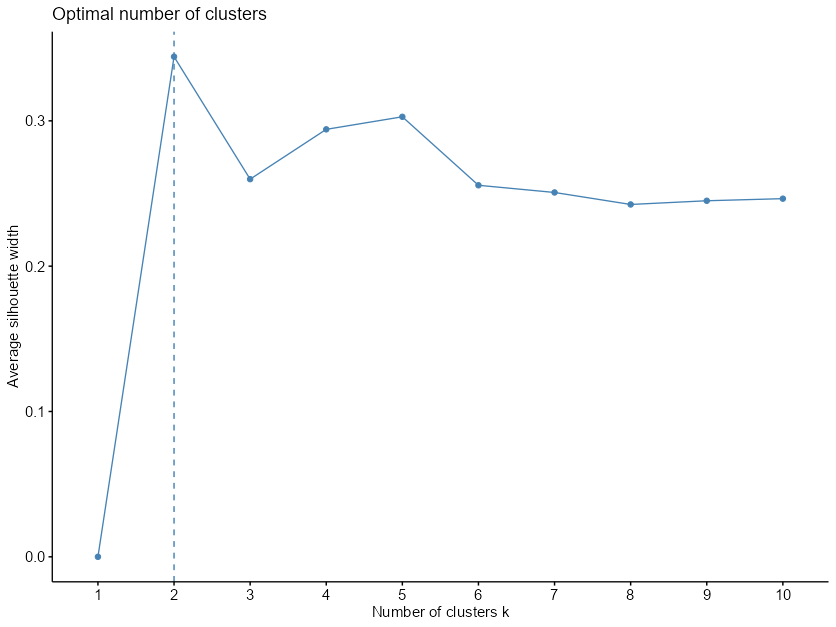

In [63]:
fviz_nbclust(X_cluster, kmeans, method = "silhouette")

Clustering k = 1,2,..., K.max (= 10): .. done
Bootstrapping, b = 1,2,..., B (= 100)  [one "." per sample]:
.................................................. 50 
.................................................. 100 


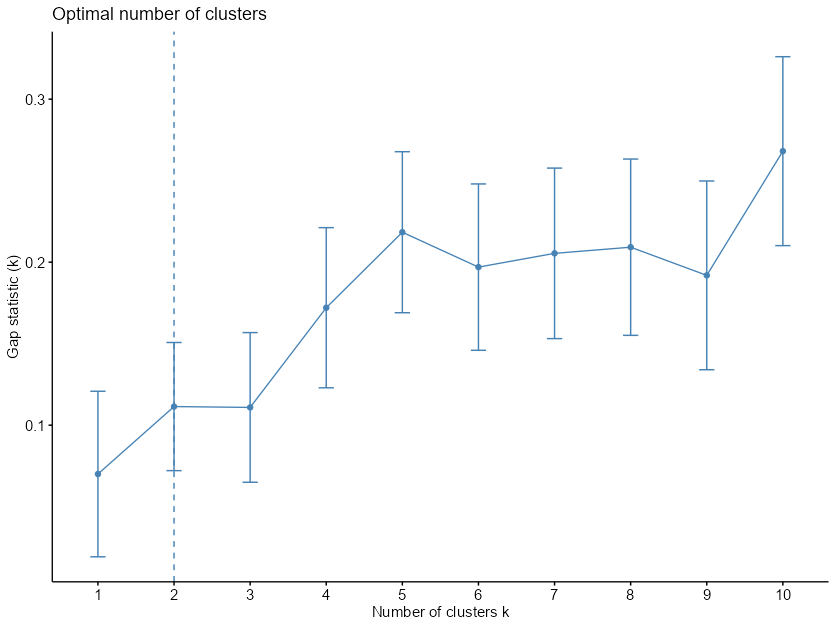

In [64]:
fviz_nbclust(X_cluster, kmeans, method = "gap_stat")

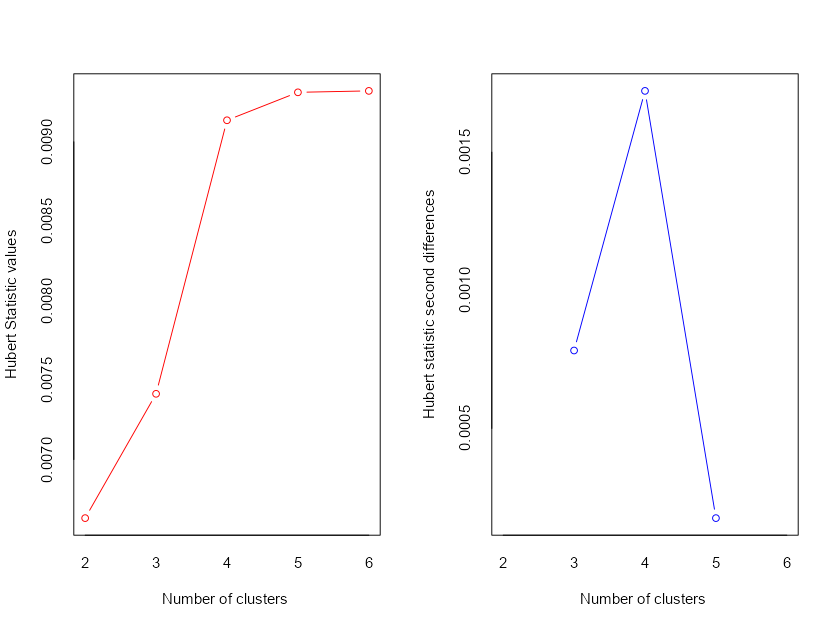

*** : The Hubert index is a graphical method of determining the number of clusters.
                In the plot of Hubert index, we seek a significant knee that corresponds to a 
                significant increase of the value of the measure i.e the significant peak in Hubert
                index second differences plot. 
 


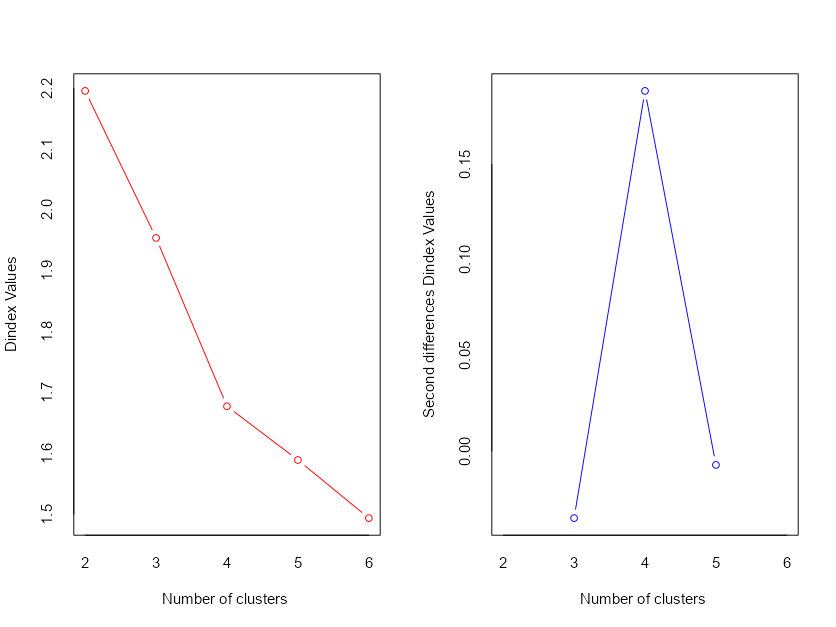

*** : The D index is a graphical method of determining the number of clusters. 
                In the plot of D index, we seek a significant knee (the significant peak in Dindex
                second differences plot) that corresponds to a significant increase of the value of
                the measure. 
 
******************************************************************* 
* Among all indices:                                                
* 10 proposed 2 as the best number of clusters 
* 3 proposed 3 as the best number of clusters 
* 8 proposed 4 as the best number of clusters 
* 3 proposed 6 as the best number of clusters 

                   ***** Conclusion *****                            
 
* According to the majority rule, the best number of clusters is  2 
 
 
******************************************************************* 


In [65]:
resumclust <- NbClust(
  X_cluster,
  distance = "euclidean",
  min.nc = 2,
  max.nc = 6,
  method = "kmeans",
  index = "all"
)

In [66]:
set.seed(123)

k2 <- kmeans(X_cluster, centers = 2, nstart = 50)
k3 <- kmeans(X_cluster, centers = 3, nstart = 50)
k4 <- kmeans(X_cluster, centers = 4, nstart = 50)

dist_cluster <- dist(X_cluster)

sil_k2 <- silhouette(k2$cluster, dist_cluster)
sil_k3 <- silhouette(k3$cluster, dist_cluster)
sil_k4 <- silhouette(k4$cluster, dist_cluster)

cat("Silhouette promedio k = 2:", mean(sil_k2[, 3]), "\n")

Silhouette promedio k = 2: 0.3441421 


In [67]:
cat("Silhouette promedio k = 3:", mean(sil_k3[, 3]), "\n")

Silhouette promedio k = 3: 0.2654215 


In [68]:
cat("Silhouette promedio k = 4:", mean(sil_k4[, 3]), "\n")

Silhouette promedio k = 4: 0.2941523 


In [69]:
cf2 <- clusterboot(
  X_cluster,
  clustermethod = kmeansCBI,
  krange = 2,
  bootmethod = c("jitter", "boot"),
  B = 100,
  seed = 123
)

jitter 1 
jitter 2 
jitter 3 
jitter 4 
jitter 5 
jitter 6 
jitter 7 
jitter 8 
jitter 9 
jitter 10 
jitter 11 
jitter 12 
jitter 13 
jitter 14 
jitter 15 
jitter 16 
jitter 17 
jitter 18 
jitter 19 
jitter 20 
jitter 21 
jitter 22 
jitter 23 
jitter 24 
jitter 25 
jitter 26 
jitter 27 
jitter 28 
jitter 29 
jitter 30 
jitter 31 
jitter 32 
jitter 33 
jitter 34 
jitter 35 
jitter 36 
jitter 37 
jitter 38 
jitter 39 
jitter 40 
jitter 41 
jitter 42 
jitter 43 
jitter 44 
jitter 45 
jitter 46 
jitter 47 
jitter 48 
jitter 49 
jitter 50 
jitter 51 
jitter 52 
jitter 53 
jitter 54 
jitter 55 
jitter 56 
jitter 57 
jitter 58 
jitter 59 
jitter 60 
jitter 61 
jitter 62 
jitter 63 
jitter 64 
jitter 65 
jitter 66 
jitter 67 
jitter 68 
jitter 69 
jitter 70 
jitter 71 
jitter 72 
jitter 73 
jitter 74 
jitter 75 
jitter 76 
jitter 77 
jitter 78 
jitter 79 
jitter 80 
jitter 81 
jitter 82 
jitter 83 
jitter 84 
jitter 85 
jitter 86 
jitter 87 
jitter 88 
jitter 89 
jitter 90 
jitter 91 
jitter 9

In [70]:
cf4 <- clusterboot(
  X_cluster,
  clustermethod = kmeansCBI,
  krange = 4,
  bootmethod = c("jitter", "boot"),
  B = 100,
  seed = 123
)

jitter 1 
jitter 2 
jitter 3 
jitter 4 
jitter 5 
jitter 6 
jitter 7 
jitter 8 
jitter 9 
jitter 10 
jitter 11 
jitter 12 
jitter 13 
jitter 14 
jitter 15 
jitter 16 
jitter 17 
jitter 18 
jitter 19 
jitter 20 
jitter 21 
jitter 22 
jitter 23 
jitter 24 
jitter 25 
jitter 26 
jitter 27 
jitter 28 
jitter 29 
jitter 30 
jitter 31 
jitter 32 
jitter 33 
jitter 34 
jitter 35 
jitter 36 
jitter 37 
jitter 38 
jitter 39 
jitter 40 
jitter 41 
jitter 42 
jitter 43 
jitter 44 
jitter 45 
jitter 46 
jitter 47 
jitter 48 
jitter 49 
jitter 50 
jitter 51 
jitter 52 
jitter 53 
jitter 54 
jitter 55 
jitter 56 
jitter 57 
jitter 58 
jitter 59 
jitter 60 
jitter 61 
jitter 62 
jitter 63 
jitter 64 
jitter 65 
jitter 66 
jitter 67 
jitter 68 
jitter 69 
jitter 70 
jitter 71 
jitter 72 
jitter 73 
jitter 74 
jitter 75 
jitter 76 
jitter 77 
jitter 78 
jitter 79 
jitter 80 
jitter 81 
jitter 82 
jitter 83 
jitter 84 
jitter 85 
jitter 86 
jitter 87 
jitter 88 
jitter 89 
jitter 90 
jitter 91 
jitter 9

In [71]:
print(cf2)

* Cluster stability assessment *
Cluster method:  kmeans 
Full clustering results are given as parameter result
of the clusterboot object, which also provides further statistics
of the resampling results.
Number of resampling runs:  100 

Number of clusters found in data:  2 

 Clusterwise Jaccard jittering mean:
[1] 0.9886667 0.9908205
dissolved:
[1] 0 0
recovered:
[1] 99 99
 Clusterwise Jaccard bootstrap (omitting multiple points) mean:
[1] 0.9005511 0.9101807
dissolved:
[1] 4 7
recovered:
[1] 83 88


In [72]:
print(cf4)

* Cluster stability assessment *
Cluster method:  kmeans 
Full clustering results are given as parameter result
of the clusterboot object, which also provides further statistics
of the resampling results.
Number of resampling runs:  100 

Number of clusters found in data:  4 

 Clusterwise Jaccard jittering mean:
[1] 0.6402778 0.7576623 0.8096771 0.7719048
dissolved:
[1] 53 15 13 10
recovered:
[1] 47 35 84 48
 Clusterwise Jaccard bootstrap (omitting multiple points) mean:
[1] 0.6954048 0.7038611 0.7255635 0.7701667
dissolved:
[1] 40 27 29 25
recovered:
[1] 44 38 47 50


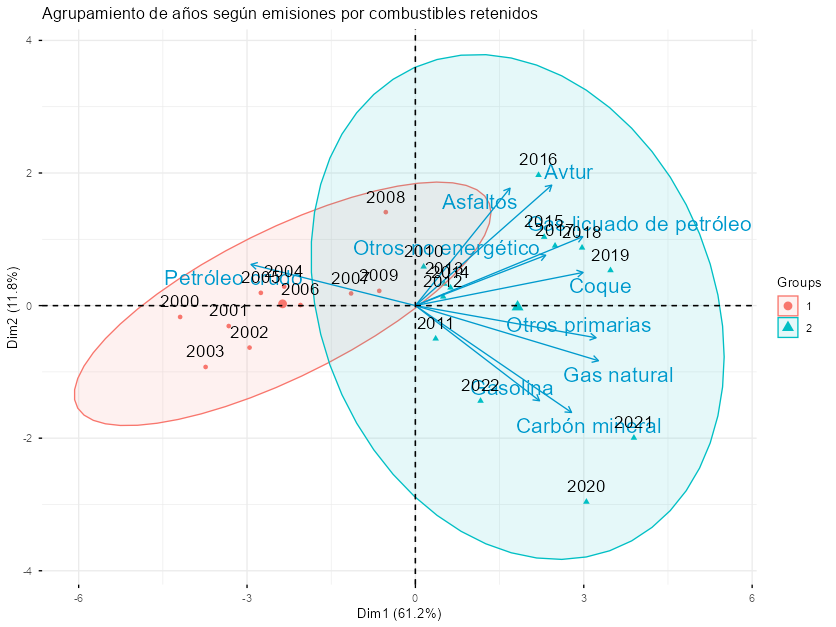

In [73]:
fviz_pca_biplot(
  pca,
  label = "var",
  geom.ind = "point",
  col.var = "#009ACD",
  habillage = as.factor(k2$cluster),
  addEllipses = TRUE,
  repel = TRUE,
  labelsize = 6,
  title = "Agrupamiento de años según emisiones por combustibles retenidos"
) +
  geom_text(
    aes(label = years),
    vjust = -0.8,
    size = 5,
    color = "black"
  )

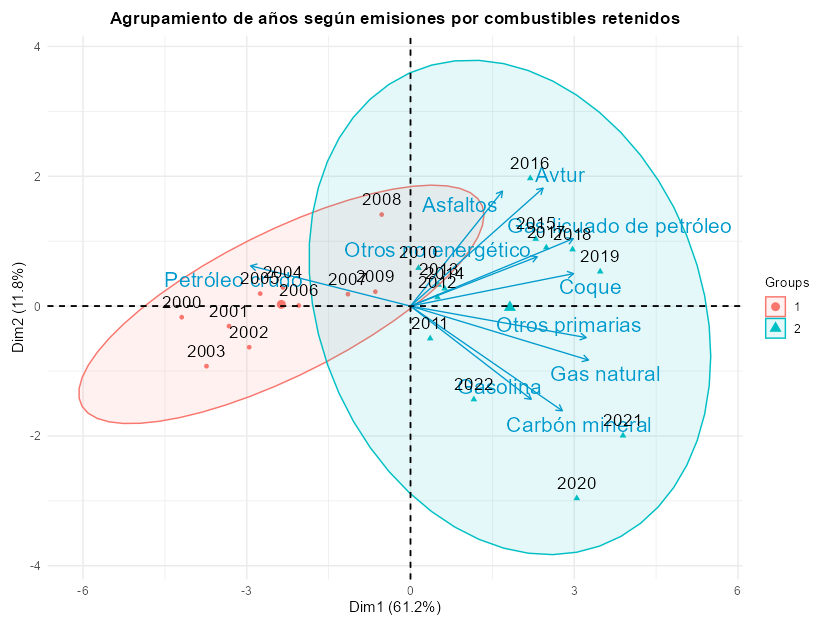

In [74]:
grafico_pca <- fviz_pca_biplot(
  pca,
  label = "var",
  geom.ind = "point",
  col.var = "#009ACD",
  habillage = as.factor(k2$cluster),
  addEllipses = TRUE,
  repel = TRUE,
  labelsize = 6,
  title = "Agrupamiento de años según emisiones por combustibles retenidos"
) +
  geom_text(
    aes(label = years),
    vjust = -0.8,
    size = 5,
    color = "black"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(
      hjust = 0.5,
      size = 14,
      face = "bold"
    ),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 10),
    legend.title = element_text(size = 11),
    legend.text = element_text(size = 10),
    plot.margin = margin(10, 15, 10, 10)
  )

grafico_pca

In [75]:
ggsave(
  filename = paste0(
    "C:/Users/user/CO2-emsiones-tipo-combustible/",
    "results/figures/biplot_pca_agrupamiento.tiff"
  ),
  plot = grafico_pca,
  device = "tiff",
  width = 10,
  height = 8,
  units = "in",
  dpi = 600,
  compression = "lzw",
  bg = "white"
)

### Dendograma (using filtered dataset)

Warning message:
The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as of ggplot2
3.3.4.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <]8;;https://github.com/kassambara/factoextra/issueshttps://github.com/kassambara/factoextra/issues]8;;>.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was generated. 


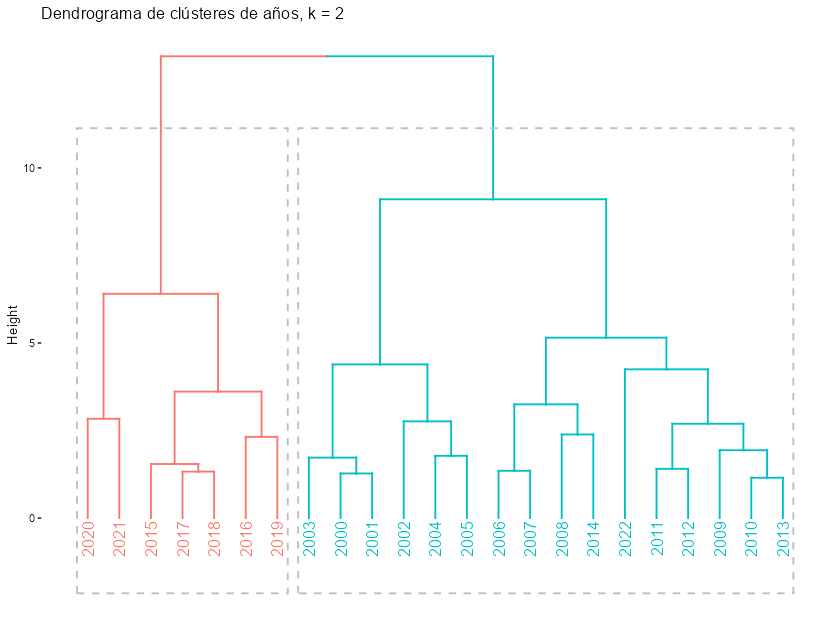

In [76]:
res2 <- hcut(X_cluster, k = 2, stand = FALSE)

fviz_dend(
  res2,
  cex = 0.9,
  k = 2,
  rect = TRUE,
  show_labels = TRUE
) +
  labs(title = "Dendrograma de clústeres de años, k = 2")

#### perfiles de cluster

In [77]:
table(k2$cluster)


 1  2 
10 13 

In [78]:
# --- Centroides en unidades originales (interpretables para el manuscrito) ---
perfil_original <- data_filtered_df[, -c(1, 2)] |>
  as.data.frame() |>
  mutate(Cluster = factor(k2$cluster)) |>
  group_by(Cluster) |>
  summarise(across(everything(), mean), n = n(), .groups = "drop") |>
  mutate(across(where(is.numeric) & !n, ~ round(.x, 1)))

perfil_original

# A tibble: 2 × 12
  Cluster Asfaltos Avtur `Carbón mineral` Coque `Gas licuado de petróleo` `Gas natural`
  <fct>      <dbl> <dbl>            <dbl> <dbl>                     <dbl>         <dbl>
1 1           54.3  568.            1871.  777.                     1780.          636.
2 2          106.   871.            3858. 1415.                     2408.         2532 
# ℹ 5 more variables: Gasolina <dbl>, `Otros no energético` <dbl>, `Otros primarias` <dbl>,
#   `Petróleo crudo` <dbl>, n <int>

In [79]:
# --- Centroides estandarizados (z-scores; = k2$centers directamente, ya que
# X_cluster ya estaba escalado antes de correr kmeans) ---
perfil_z <- as.data.frame(k2$centers) |>
  mutate(Cluster = factor(seq_len(n()))) |>
  relocate(Cluster) |>
  mutate(across(where(is.numeric), ~ round(.x, 2)))

perfil_z

  Cluster Asfaltos Avtur Carbón mineral Coque Gas licuado de petróleo Gas natural Gasolina
1       1    -0.61 -0.67          -0.63 -0.79                   -0.70       -1.00    -0.69
2       2     0.47  0.51           0.49  0.61                    0.54        0.77     0.53
  Otros no energético Otros primarias Petróleo crudo
1               -0.46           -0.93           0.92
2                0.36            0.71          -0.71

In [80]:
# --- Tabla combinada lista para el manuscrito: Variable | Media_C1 | Media_C2 | Z_C1 | Z_C2 ---
medias_long <- perfil_original |>
  select(-n) |>
  pivot_longer(-Cluster, names_to = "Variable", values_to = "Media") |>
  pivot_wider(names_from = Cluster, values_from = Media, names_prefix = "Media_C")

z_long <- as.data.frame(k2$centers) |>
  mutate(Cluster = factor(seq_len(n()))) |>
  pivot_longer(-Cluster, names_to = "Variable", values_to = "Z") |>
  pivot_wider(names_from = Cluster, values_from = Z, names_prefix = "Z_C")

tabla_manuscrito <- medias_long |>
  left_join(z_long, by = "Variable") |>
  mutate(across(where(is.numeric), ~ round(.x, 2))) |>
  arrange(desc(abs(Z_C1 - Z_C2)))  # ordena por variable más discriminante entre clusters

tabla_manuscrito

# A tibble: 10 × 5
   Variable                Media_C1 Media_C2  Z_C1  Z_C2
   <chr>                      <dbl>    <dbl> <dbl> <dbl>
 1 Gas natural                636.    2532   -1     0.77
 2 Otros primarias             28       36.1 -0.93  0.71
 3 Petróleo crudo            5934.    3385    0.92 -0.71
 4 Coque                      777.    1415.  -0.79  0.61
 5 Gas licuado de petróleo   1780.    2408.  -0.7   0.54
 6 Gasolina                  1660.    2350.  -0.69  0.53
 7 Avtur                      568.     871.  -0.67  0.51
 8 Carbón mineral            1871.    3858.  -0.63  0.49
 9 Asfaltos                    54.3    106.  -0.61  0.47
10 Otros no energético         46       61   -0.46  0.36

#### Perfil visual (heatmap de z-scores por cluster)

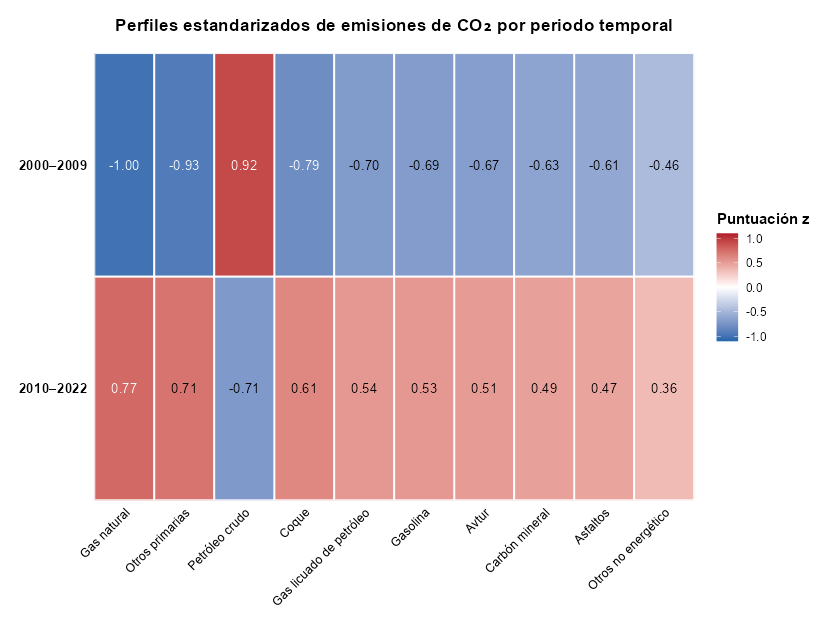

In [81]:
# ==========================================================
# FIGURA 3. Heatmap de perfiles estandarizados por periodo
# ==========================================================

# 1. Identificar automáticamente el periodo de cada clúster
periodos_cluster <- tibble(
  Año = years,
  Cluster = k2$cluster
) |>
  group_by(Cluster) |>
  summarise(
    Inicio = min(Año),
    Fin = max(Año),
    Periodo = paste0(Inicio, "\u2013", Fin),
    .groups = "drop"
  ) |>
  arrange(Inicio)

# Orden cronológico de los periodos
niveles_periodo <- periodos_cluster$Periodo

# 2. Ordenar variables según la diferencia absoluta
#    entre los centroides de ambos clústeres
orden_variables <- names(
  sort(
    abs(k2$centers[1, ] - k2$centers[2, ]),
    decreasing = TRUE
  )
)

# 3. Preparar los centroides estandarizados en formato largo
perfil_heatmap <- as.data.frame(k2$centers) |>
  mutate(Cluster = seq_len(n())) |>
  left_join(
    periodos_cluster |>
      select(Cluster, Periodo),
    by = "Cluster"
  ) |>
  pivot_longer(
    cols = -c(Cluster, Periodo),
    names_to = "Variable",
    values_to = "Z"
  ) |>
  mutate(
    Variable = factor(
      Variable,
      levels = orden_variables
    ),

    # Se invierte el orden para que el periodo inicial
    # aparezca en la parte superior del gráfico
    Periodo = factor(
      Periodo,
      levels = rev(niveles_periodo)
    )
  )

# 4. Establecer límites simétricos para la escala cromática
limite_z <- ceiling(
  max(abs(perfil_heatmap$Z)) * 10
) / 10

# 5. Construir la figura
figura3 <- ggplot(
  perfil_heatmap,
  aes(
    x = Variable,
    y = Periodo,
    fill = Z
  )
) +
  geom_tile(
    color = "white",
    linewidth = 0.7
  ) +

  # Texto blanco en las celdas más oscuras
  geom_text(
    aes(
      label = sprintf("%.2f", Z),
      color = abs(Z) >= 0.75
    ),
    size = 3.8
  ) +

  scale_color_manual(
    values = c(
      "FALSE" = "black",
      "TRUE" = "white"
    ),
    guide = "none"
  ) +

  scale_fill_gradient2(
    low = "#2166AC",
    mid = "white",
    high = "#B2182B",
    midpoint = 0,
    limits = c(-limite_z, limite_z),
    name = "Puntuación z"
  ) +

  scale_x_discrete(
    expand = c(0, 0)
  ) +

  scale_y_discrete(
    expand = c(0, 0)
  ) +

  labs(
    title = "Perfiles estandarizados de emisiones de CO\u2082 por periodo temporal",
    x = NULL,
    y = NULL
  ) +

  theme_minimal(base_size = 12) +

  theme(
    panel.grid = element_blank(),

    axis.text.x = element_text(
      angle = 45,
      hjust = 1,
      vjust = 1,
      size = 10,
      color = "black"
    ),

    axis.text.y = element_text(
      size = 11,
      face = "bold",
      color = "black"
    ),

    plot.title = element_text(
      size = 14,
      face = "bold",
      hjust = 0.5,
      margin = margin(b = 15)
    ),

    legend.title = element_text(
      face = "bold"
    ),

    plot.margin = margin(
      t = 15,
      r = 15,
      b = 15,
      l = 15
    )
  )

# Mostrar la figura
figura3

In [82]:
ggsave(
  filename = "C:/Users/user/CO2-emsiones-tipo-combustible/results/figures/Figura_3_heatmap_perfiles_estandarizados.tiff",
  plot = figura3,
  width = 10,
  height = 4.8,
  units = "in",
  dpi = 300,
  compression = "lzw",
  bg = "white"
)

In [83]:
# ==========================================================
# TABLA 3. Centroides originales y estandarizados por periodo
# ==========================================================

# Centroides en unidades originales
centroides_originales <- data_filtered_df[, -c(1, 2)] |>
  as.data.frame() |>
  mutate(
    Cluster = k2$cluster,
    Periodo = case_when(
      Cluster == periodos_cluster$Cluster[
        which.min(periodos_cluster$Inicio)
      ] ~ "2000–2007",

      TRUE ~ "2008–2022"
    )
  ) |>
  group_by(Periodo) |>
  summarise(
    across(where(is.numeric), mean),
    .groups = "drop"
  ) |>
  pivot_longer(
    cols = -Periodo,
    names_to = "Variable",
    values_to = "Media_original"
  )

# Centroides estandarizados
centroides_z <- as.data.frame(k2$centers) |>
  mutate(Cluster = seq_len(n())) |>
  left_join(
    periodos_cluster |>
      select(Cluster, Periodo),
    by = "Cluster"
  ) |>
  pivot_longer(
    cols = -c(Cluster, Periodo),
    names_to = "Variable",
    values_to = "Z"
  ) |>
  select(-Cluster)

# Combinar ambas escalas
tabla3 <- centroides_originales |>
  left_join(
    centroides_z,
    by = c("Periodo", "Variable")
  ) |>
  pivot_wider(
    names_from = Periodo,
    values_from = c(Media_original, Z)
  ) |>
  transmute(
    Combustible = Variable,
    `Media original 2000–2007` =
      `Media_original_2000–2007`,
    `z 2000–2007` =
      `Z_2000–2007`,
    `Media original 2008–2022` =
      `Media_original_2008–2022`,
    `z 2008–2022` =
      `Z_2008–2022`
  ) |>
  mutate(
    across(
      starts_with("Media"),
      ~ round(.x, 1)
    ),
    across(
      starts_with("z"),
      ~ round(.x, 2)
    )
  ) |>
  arrange(
    desc(
      abs(`z 2000–2007` - `z 2008–2022`)
    )
  )

tabla3

# A tibble: 11 × 5
   Combustible     Media original 2000–…¹ `z 2000–2007` Media original 2008–…² `z 2008–2022`
   <chr>                            <dbl>         <dbl>                  <dbl>         <dbl>
 1 Asfaltos                          54.3            NA                  106.             NA
 2 Avtur                            568.             NA                  871.             NA
 3 Carbón mineral                  1871.             NA                 3858.             NA
 4 Coque                            777.             NA                 1415.             NA
 5 Gas licuado de…                 1780.             NA                 2408.             NA
 6 Gas natural                      636.             NA                 2532              NA
 7 Gasolina                        1660.             NA                 2350.             NA
 8 Otros no energ…                   46              NA                   61              NA
 9 Otros primarias                   28            

In [84]:
# ==========================================================
# GUARDAR TABLA 3
# ==========================================================

# Ruta de salida
table_dir <- "C:/Users/user/CO2-emsiones-tipo-combustible/results/tables"

# Crear la carpeta si no existe
dir.create(
  table_dir,
  recursive = TRUE,
  showWarnings = FALSE
)

# Instalar writexl si no está disponible
if (!requireNamespace("writexl", quietly = TRUE)) {
  install.packages("writexl")
}

# Guardar en formato Excel
writexl::write_xlsx(
  x = list(
    "Tabla 3" = tabla3
  ),
  path = file.path(
    table_dir,
    "Tabla_3_centroides_originales_estandarizados.xlsx"
  )
)

# Guardar también en formato CSV
readr::write_csv(
  tabla3,
  file = file.path(
    table_dir,
    "Tabla_3_centroides_originales_estandarizados.csv"
  ),
  na = ""
)

# Confirmar las rutas
cat(
  "Tabla Excel guardada en:\n",
  file.path(
    table_dir,
    "Tabla_3_centroides_originales_estandarizados.xlsx"
  ),
  "\n\nTabla CSV guardada en:\n",
  file.path(
    table_dir,
    "Tabla_3_centroides_originales_estandarizados.csv"
  ),
  "\n"
)

Tabla Excel guardada en:
 C:/Users/user/CO2-emsiones-tipo-combustible/results/tables/Tabla_3_centroides_originales_estandarizados.xlsx 

Tabla CSV guardada en:
 C:/Users/user/CO2-emsiones-tipo-combustible/results/tables/Tabla_3_centroides_originales_estandarizados.csv 


#### Listado explícito año → cluster

In [85]:
tabla_anio_cluster <- tibble(
  Año = years,
  Cluster = k2$cluster
) |>
  arrange(Año)

print(tabla_anio_cluster, n = Inf)

# A tibble: 23 × 2
     Año Cluster
   <dbl>   <int>
 1  2000       1
 2  2001       1
 3  2002       1
 4  2003       1
 5  2004       1
 6  2005       1
 7  2006       1
 8  2007       1
 9  2008       1
10  2009       1
11  2010       2
12  2011       2
13  2012       2
14  2013       2
15  2014       2
16  2015       2
17  2016       2
18  2017       2
19  2018       2
20  2019       2
21  2020       2
22  2021       2
23  2022       2
